In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [4]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [5]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [7]:
df.shape

(10000, 11)

In [8]:
df.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

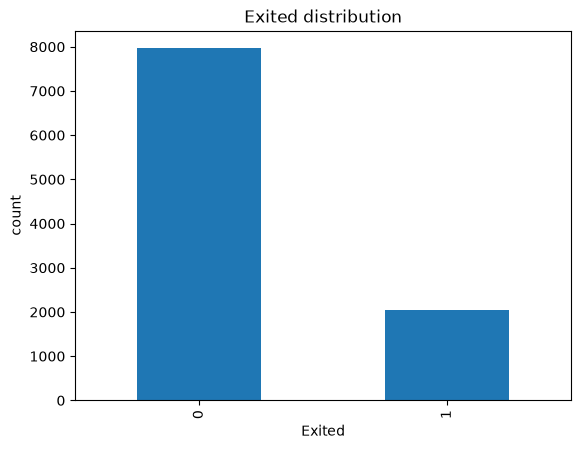

In [9]:
df['Exited'].value_counts().plot(kind="bar")
plt.title("Exited distribution")
plt.xlabel("Exited")
plt.ylabel("count")
plt.show()

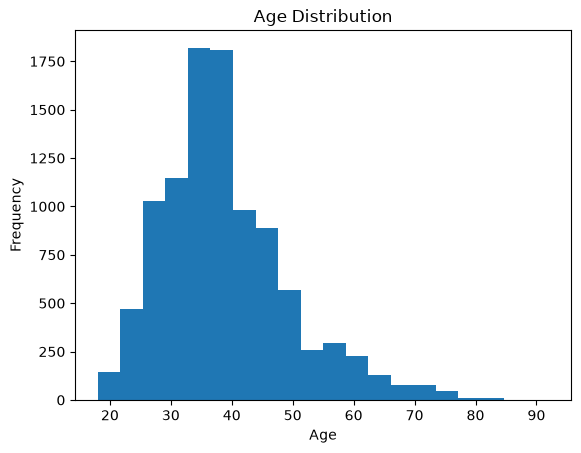

In [10]:
plt.hist(df['Age'],bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

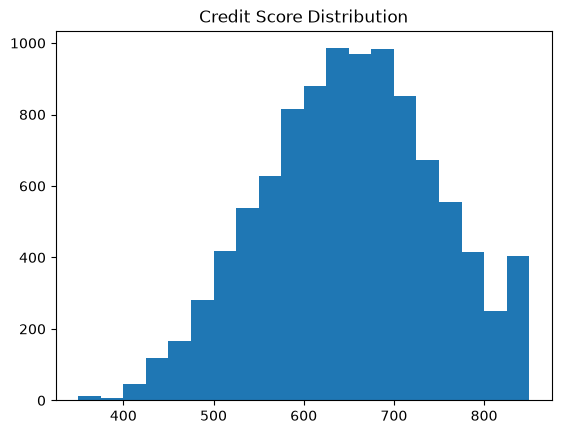

In [11]:
plt.hist(df["CreditScore"], bins=20)
plt.title("Credit Score Distribution")
plt.show()

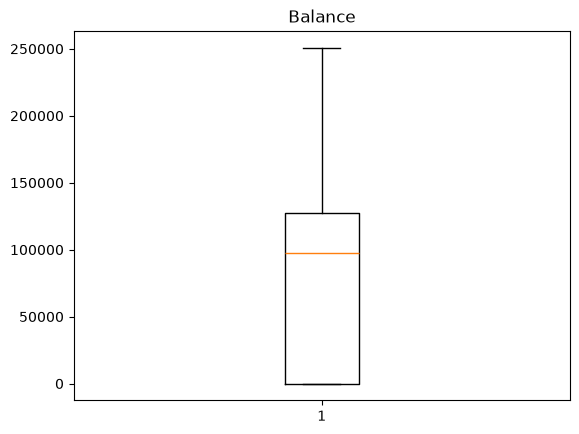

In [12]:
plt.boxplot(df["Balance"])

plt.title("Balance")
plt.show()

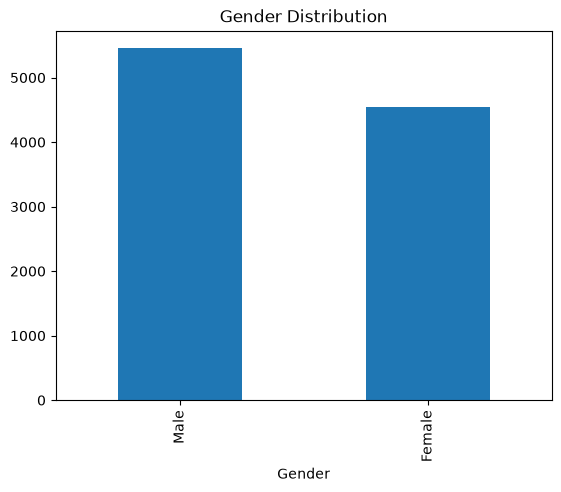

In [13]:
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.show()

<Axes: xlabel='Geography'>

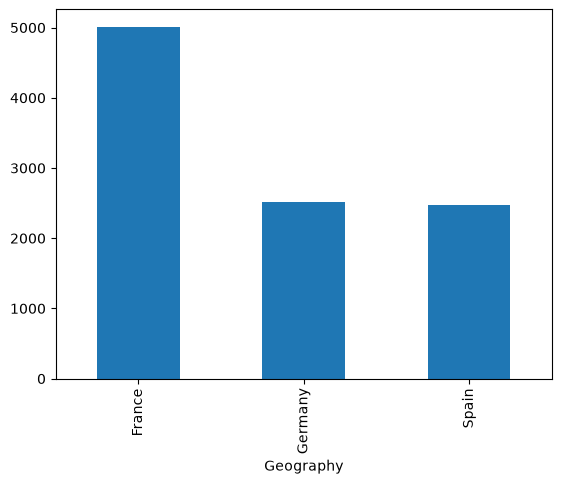

In [14]:
df['Geography'].value_counts().plot(kind='bar')

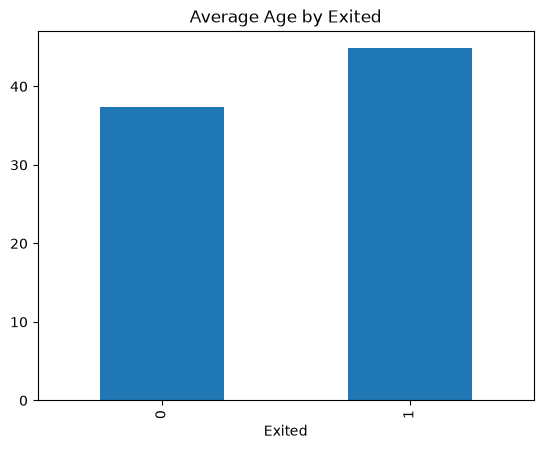

In [15]:
df.groupby("Exited")["Age"].mean().plot(kind="bar")
plt.title("Average Age by Exited")
plt.show()

<Axes: xlabel='Exited'>

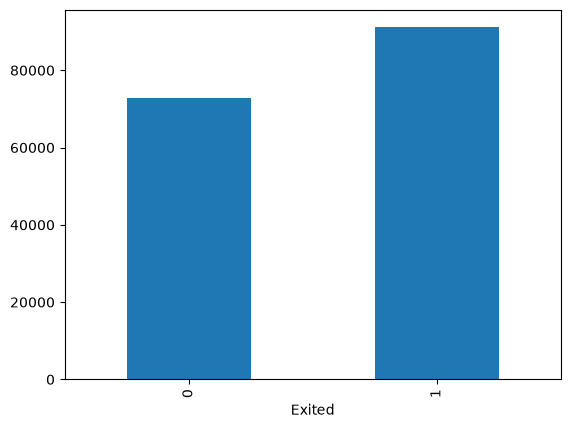

In [16]:
df.groupby("Exited")["Balance"].mean().plot(kind="bar")

In [17]:
df['Gender'] = df['Gender'].replace({'Female': 1, 'Male': 0})

In [18]:
df['Gender']=df['Gender'].astype(int)

In [19]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,1,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,1,41,1,83807.86,1,0,1,112542.58,0
2,502,France,1,42,8,159660.80,3,1,0,113931.57,1
3,699,France,1,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,1,43,2,125510.82,1,1,1,79084.10,0


In [20]:
df.dtypes

CreditScore          int64
Geography              str
Gender               int64
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [21]:
df=pd.get_dummies(data=df,columns=['Geography'])
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,1,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,1,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,1,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,1,43,2,125510.82,1,1,1,79084.10,0,False,False,True


In [22]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()
cols_to_scale=['CreditScore','Age','Tenure','Balance','EstimatedSalary']
df[cols_to_scale]=scalar.fit_transform(df[cols_to_scale])
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,0.538,1,0.324324,0.2,0.000000,1,1,1,0.506735,1,True,False,False
1,0.516,1,0.310811,0.1,0.334031,1,0,1,0.562709,0,False,False,True
2,0.304,1,0.324324,0.8,0.636357,3,1,0,0.569654,1,True,False,False
3,0.698,1,0.283784,0.1,0.000000,2,0,0,0.469120,0,True,False,False
4,1.000,1,0.337838,0.2,0.500246,1,1,1,0.395400,0,False,False,True


In [23]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,0.538,1,0.324324,0.2,0.000000,1,1,1,0.506735,1,True,False,False
1,0.516,1,0.310811,0.1,0.334031,1,0,1,0.562709,0,False,False,True
2,0.304,1,0.324324,0.8,0.636357,3,1,0,0.569654,1,True,False,False
3,0.698,1,0.283784,0.1,0.000000,2,0,0,0.469120,0,True,False,False
4,1.000,1,0.337838,0.2,0.500246,1,1,1,0.395400,0,False,False,True


In [25]:
x=df.drop('Exited',axis='columns')
y=df['Exited']
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=5)

In [26]:
x_train.shape

(7500, 12)

In [27]:
x_test.shape

(2500, 12)

In [30]:
import tensorflow as tf
from tensorflow import keras
model=keras.Sequential([
  keras.layers.Dense(12,input_shape=(12,),activation='relu'),
  keras.layers.Dense(8,activation='relu'),
  keras.layers.Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train,y_train,epochs=100)

Epoch 1/100


c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7531 - loss: 0.5492
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7952 - loss: 0.4799
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4673
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7995 - loss: 0.4553
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8085 - loss: 0.4420
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8132 - loss: 0.4277
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8164 - loss: 0.4154
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8196 - loss: 0.4056
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8204 - loss: 0.3983
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8219 - loss: 0.3927
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8225 - loss: 0.3892
Epoch 12/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [51]:
model.evaluate(x_test,y_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8580 - loss: 0.3469


[0.34685832262039185, 0.8579999804496765]

In [52]:
yp=model.predict(x_test)
yp[:5]

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[0.02621049],
       [0.0698413 ],
       [0.03723357],
       [0.10173769],
       [0.05223728]], dtype=float32)

In [53]:
y_pred=[]
for ele in yp:
  if ele>0.5:
    y_pred.append(1)
  else:
    y_pred.append(0)

In [54]:
y_pred[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

In [55]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1999
           1       0.75      0.44      0.55       501

    accuracy                           0.86      2500
   macro avg       0.81      0.70      0.74      2500
weighted avg       0.85      0.86      0.84      2500



Text(95.83333333333333, 0.5, 'actual')

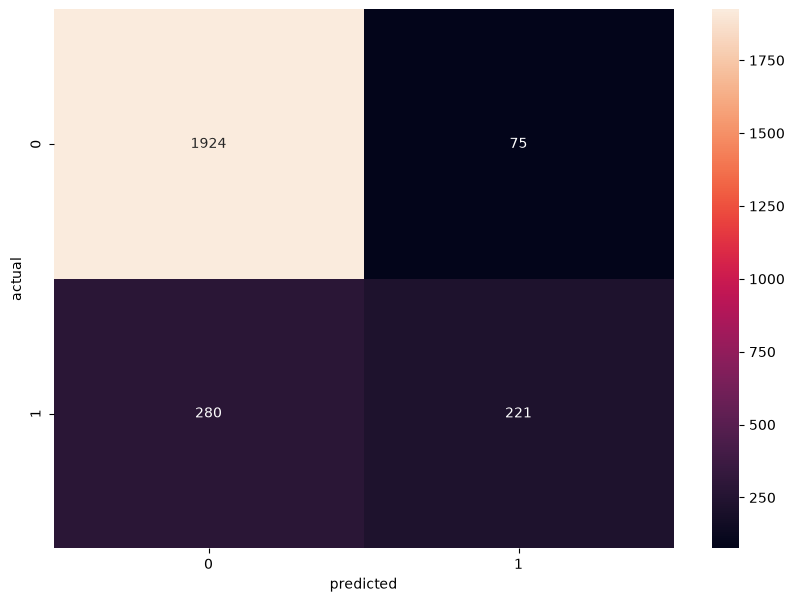

In [56]:
import seaborn as sns
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot= True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('actual')

In [68]:
tn = 1924
fp = 75
fn = 280
tp = 221
total=tp+tn+fp+fn
accuracy=(tp+tn)/total
print(total)
print(accuracy)

2500
0.858


In [69]:
precison=tp/(tp+fp)
print(precison)

0.7466216216216216


In [70]:
recall=tp/(tp+fn)
print(recall)

0.4411177644710579


In [71]:
f1=2*(precison*recall)/(precison+recall)
print(f1)

0.5545796737766625
